# Label EDA and scope policy (Tasks #2a, #2b)

Parses the document labels, checks them for normalization problems and missingness, and applies the scope policy in `data/scope.py`.
The policy and its reasoning are written up in [`docs/scope_policy.md`](../docs/scope_policy.md).

Run `Legal2B_Group_Notebook.ipynb` (or `python data/load_data.py`) first so the dataset is cached in `data/raw/`.

In [1]:
# Colab only: uncomment after cloning the repository.
# %cd /content/Legal-2B-multimodal-document-understanding/notebooks

In [2]:
import sys
sys.path.insert(0, "..")

import collections
import json

import jsonschema
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset

from data.load_data import CACHE_DIR, DATASET, HEAD_CLASS_MIN_COUNT, build_labels
from data.scope import IN_SCOPE, OUT_OF_SCOPE, TAIL, apply_scope_policy

ds = load_dataset(DATASET, split="test", cache_dir=str(CACHE_DIR))
text = ds.remove_columns("image")  # skip image decoding for the text-only checks

/Users/dianalucero/Developer/Programs/breakthrough-tech/Legal-2B-multimodal-document-understanding/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Raw labels before normalization

`metadata` is a JSON string. Look at the raw `format` values before the loader strips and upper-cases them.

In [3]:
metas = [json.loads(m) for m in text["metadata"]]
raw_formats = collections.Counter(m.get("format") for m in metas)
print(f"{len(raw_formats)} raw format values")

needs_cleaning = {f: n for f, n in raw_formats.items() if f != f.strip().upper()}
print("Values changed by strip().upper():", needs_cleaning)

cleaned = collections.Counter(f.strip().upper() for f in raw_formats.elements())
print(f"{len(cleaned)} format values after normalization")

37 raw format values
Values changed by strip().upper(): {'SCANNED_TABLE ': 1}
36 format values after normalization


Only `"SCANNED_TABLE "` (trailing space) needs cleaning; no case variants. 37 → 36 labels.

Some labels look like near-duplicates by name (`NUTRITION` / `PHOTO_NUTRITION`, `CHART` / `PHOTO_CHART`, `TABLE` / `SCANNED_TABLE` / `PHOTO_TABLE` / `WEB_TABLE`, `FORM` / `SCANNED_FORM`).
They are **not** merged: the prefix describes how the document was captured, and every one of these is out of scope anyway (see §5), so merging would not change the classifier.

## 2. Metadata keys and missingness

In [4]:
key_sets = collections.Counter(tuple(sorted(m)) for m in metas)
for keys, n in key_sets.most_common():
    print(f"{n:4}  {keys}")

 833  ('documentQuality', 'fontFamily', 'format')
 124  ('documentQuality', 'format')
  43  ('documentQuality', 'fontFamily', 'format', 'rotation')


In [5]:
labels = apply_scope_policy(build_labels())
labels["font_family"] = [m.get("fontFamily") for m in metas]
labels["rotation"] = [m.get("rotation") for m in metas]

missing = pd.DataFrame({
    "missing fontFamily": labels["font_family"].isna().groupby(labels["format"]).sum(),
    "has rotation": labels["rotation"].notna().groupby(labels["format"]).sum(),
})
print("rotation values:", labels["rotation"].value_counts().to_dict())
missing[(missing > 0).any(axis=1)]

rotation values: {90.0: 18, 270.0: 13, 180.0: 12}


,missing fontFamily,has rotation
format,,
ACCOUNT_STATEMENT,0,3
BANK_CHECK,0,3
CAPTCHA,1,0
CHART,49,0
COMMERCIAL_LEASE_AGREEMENT,0,3
CREDIT_CARD_STATEMENT,0,3
DELIVERY_NOTE,0,3
DIAGRAM,1,0
DRIVER_LICENSE,4,0


- `format` and `documentQuality` are present on every row. No missing labels.
- `fontFamily` is missing on 124 rows: all 75 tail documents plus all 49 `CHART` documents.
- `rotation` appears on only 43 rows (90 / 180 / 270°). The image may need rotating before OCR or embedding. We assume absent means 0°; worth spot-checking a few images.

## 3. Missingness and validity of the other columns

In [6]:
def parses(s):
    if s is None or not s.strip():
        return "missing"
    try:
        json.loads(s)
        return "ok"
    except json.JSONDecodeError:
        return "bad_json"

checks = pd.DataFrame({
    "json_schema": [parses(s) for s in text["json_schema"]],
    "true_json_output": [parses(s) for s in text["true_json_output"]],
    "true_markdown_output": ["missing" if not s or not s.strip() else "ok" for s in text["true_markdown_output"]],
})
print(checks.apply(pd.Series.value_counts).fillna(0).astype(int))
print("ids unique and 0-999:", labels["id"].is_unique and labels["id"].tolist() == list(range(1000)))

    json_schema  true_json_output  true_markdown_output
ok         1000              1000                  1000
ids unique and 0-999: True


### `true_markdown_output` is JSON-encoded

Every transcription is stored as a JSON string literal: wrapped in quotes, with newlines escaped as `\n`. Decode it with `json.loads` before using it as text (e.g. for the TF-IDF baseline), or every document gets stray quote and `\n` tokens.

In [7]:
markdown = [json.loads(s) for s in text["true_markdown_output"]]
print("wrapped in quotes:", sum(s.startswith('"') for s in text["true_markdown_output"]), "of", len(markdown))
print("decode to str:    ", sum(isinstance(m, str) for m in markdown))
print(repr(text[0]["true_markdown_output"][:60]))
print(repr(markdown[0][:60]))

wrapped in quotes: 1000 of 1000
decode to str:     1000
'"| Rank | Nation          | Gold | Silver | Bronze | Total |'
'| Rank | Nation          | Gold | Silver | Bronze | Total |\n'


Nothing is missing or unparseable. But the ground truth does not always **validate** against its own schema, which matters for the extraction stage:

In [8]:
def validate(schema_str, truth_str):
    schema = json.loads(schema_str)
    try:
        jsonschema.Draft7Validator.check_schema(schema)
    except jsonschema.SchemaError:
        return "schema itself invalid"
    errors = list(jsonschema.Draft7Validator(schema).iter_errors(json.loads(truth_str)))
    if not errors:
        return "valid"
    if all(e.validator == "type" and e.instance is None for e in errors):
        return "invalid: null in non-nullable field"
    return "invalid: other"

labels["truth_validates"] = [validate(s, t) for s, t in zip(text["json_schema"], text["true_json_output"])]
pd.crosstab(labels["format"], labels["truth_validates"]).loc[lambda t: t["valid"] < t.sum(axis=1)]

truth_validates,invalid: null in non-nullable field,schema itself invalid,valid
format,,,
BANK_CHECK,0,52,0
CHART,3,0,46
CREDIT_CARD_STATEMENT,18,0,32
DELIVERY_NOTE,31,0,20
DIAGRAM,1,0,0
DRIVER_LICENSE,2,0,2
EQUIPMENT_INSPECTION,29,0,21
FORM,2,0,5
FORM_1040,41,0,10


- All 52 `BANK_CHECK` schemas are themselves invalid JSON Schema (a malformed `anyOf`).
- 327 ground-truth outputs fail validation, and every failure is a `null` in a field typed as non-nullable.
- **In-scope impact:** `PROXY_VOTING` has 32 such rows; the other four legal types validate cleanly.

When we score extraction (November), a model that returns `null` for these fields will fail `jsonschema` while matching the ground truth. We will need to validate against a nullable-patched schema or report both numbers.

## 4. Schemas per class

In [9]:
labels["schema"] = text["json_schema"]
per_class = labels.groupby("format")["schema"].nunique().rename("distinct schemas")
per_class[labels.query("scope == @IN_SCOPE")["format"].unique()].sort_values()

format
REAL_ESTATE                    1
COMMERCIAL_LEASE_AGREEMENT     1
PETITION_FORM                  1
PATENT                        32
PROXY_VOTING                  50
Name: distinct schemas, dtype: int64

`REAL_ESTATE`, `COMMERCIAL_LEASE_AGREEMENT` and `PETITION_FORM` each use a single schema, so routing a predicted type to its schema is trivial.
`PATENT` (32 schemas) and `PROXY_VOTING` (50, one per document) do not have one fixed schema; the extraction stage will need to use each document's own schema or define a canonical one.

## 5. Class distribution and scope

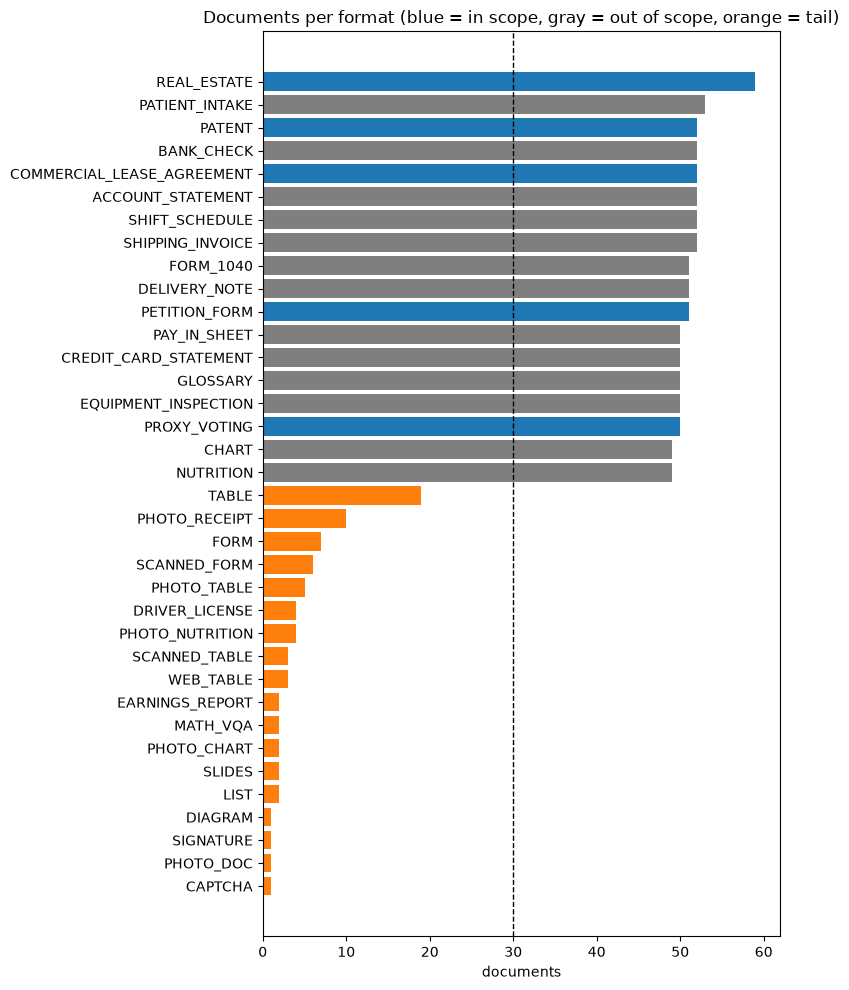

scope
out_of_scope    661
in_scope        264
tail             75
Name: count, dtype: int64

In [10]:
counts = labels.groupby(["format", "scope"]).size().reset_index(name="n").sort_values("n")
colors = counts["scope"].map({IN_SCOPE: "tab:blue", OUT_OF_SCOPE: "tab:gray", TAIL: "tab:orange"})

fig, ax = plt.subplots(figsize=(8, 10))
ax.barh(counts["format"], counts["n"], color=colors)
ax.axvline(HEAD_CLASS_MIN_COUNT, color="black", linestyle="--", linewidth=1)
ax.set_xlabel("documents")
ax.set_title("Documents per format (blue = in scope, gray = out of scope, orange = tail)")
plt.tight_layout()
plt.show()

labels["scope"].value_counts()

## 6. Document quality by scope

In [11]:
pd.crosstab(labels["scope"], labels["document_quality"], margins=True)

document_quality,CLEAN,HIGH_QUALITY,LOW_QUALITY,PHOTO,All
scope,,,,,
in_scope,90,84,86,4,264
out_of_scope,248,219,173,21,661
tail,0,0,0,75,75
All,338,303,259,100,1000


**The tail is not a random sample.** All 75 tail documents are `PHOTO` quality and lack `fontFamily`, while only 25 of 925 head documents are `PHOTO`.
Head classes look synthetic (rendered in known fonts, degraded to three quality levels); the tail looks like real photos and scans from other sources.

An out-of-scope detector evaluated on the tail could score well just by detecting "is this a photo" rather than "is this a legal type".
The scope policy handles this; see `docs/scope_policy.md`.

## 7. Tail documents that look legal

In [12]:
tail = labels[labels["scope"] == TAIL].copy()
tail["text"] = [markdown[int(i)] for i in tail["id"]]
legal_words = r"(?i)\battorneys?\b|\blaw\b|\bcourt\b|\bcounsel\b|\bagreement\b|\bcontract\b"
tail["legal_terms"] = tail["text"].str.findall(legal_words).map(lambda ws: sorted({w.lower() for w in ws}))
tail["preview"] = tail["text"].str[:90].str.replace("\n", " ", regex=False)
tail[tail["legal_terms"].str.len() > 0][["id", "format", "document_quality", "legal_terms", "preview"]]

,id,format,document_quality,legal_terms,preview
26,26,SCANNED_FORM,PHOTO,[law],"**10675** # STOUT INDUSTRIES, INC. 6425 W. F..."
30,30,FORM,PHOTO,"[attorney, law]",ATT. GEN. ADMIN. OFFICE Fax: 614-466-5087 Dec...
40,40,SCANNED_FORM,PHOTO,[contract],**ATTACHMENT A** # TRADE DIRECT MARKETING (TD...
43,43,FORM,PHOTO,"[agreement, attorney, attorneys, law]",**01/14/99** 18:36 FAX 206 623 0594 • HAGENS B...
52,52,FORM,PHOTO,[law],**FAX TRANSMISSION** **DICKSTEIN SHAPIRO MORI...
426,426,SCANNED_FORM,PHOTO,[contract],# Contract Routing Form **Route Date:** 4/29/...
469,469,EARNINGS_REPORT,PHOTO,"[agreement, contract]",# ExxonMobil ## 3Q 2024 Earnings Release Nov...
661,661,SCANNED_FORM,PHOTO,[agreement],2001 CCP Venue Wall Mural Agreement Informat...


Several tail documents use legal vocabulary even though their labels are generic (`FORM`, `SCANNED_FORM`, `LIST`): law-firm fax cover sheets, an Attorney General transmittal, contract routing forms. Skim the table above; keyword matches include some false positives.
They stay out of scope, because they are not one of the five legal types the classifier knows, but they are good hard negatives for the detector and worth reviewing in error analysis.

## 8. Images

In [13]:
sizes = pd.DataFrame([(im.width, im.height, im.mode) for im in ds["image"]], columns=["width", "height", "mode"])
print(sizes["mode"].value_counts().to_dict())
sizes[["width", "height"]].describe().round(0)

{'RGB': 636, 'RGBA': 345, 'L': 18, 'P': 1}


,width,height
count,1000.0,1000.0
mean,1942.0,2030.0
std,664.0,818.0
min,160.0,56.0
25%,1685.0,1572.0
50%,1904.0,2014.0
75%,2168.0,2462.0
max,6906.0,7016.0


- 345 images are `RGBA`, 18 grayscale (`L`), 1 palette (`P`). Convert to `RGB` before embedding.
- Sizes range from 160×56 to ~6,900×7,000 px. Cap the long edge before batching.
- No duplicate images or duplicate transcriptions (checked by hash during EDA).

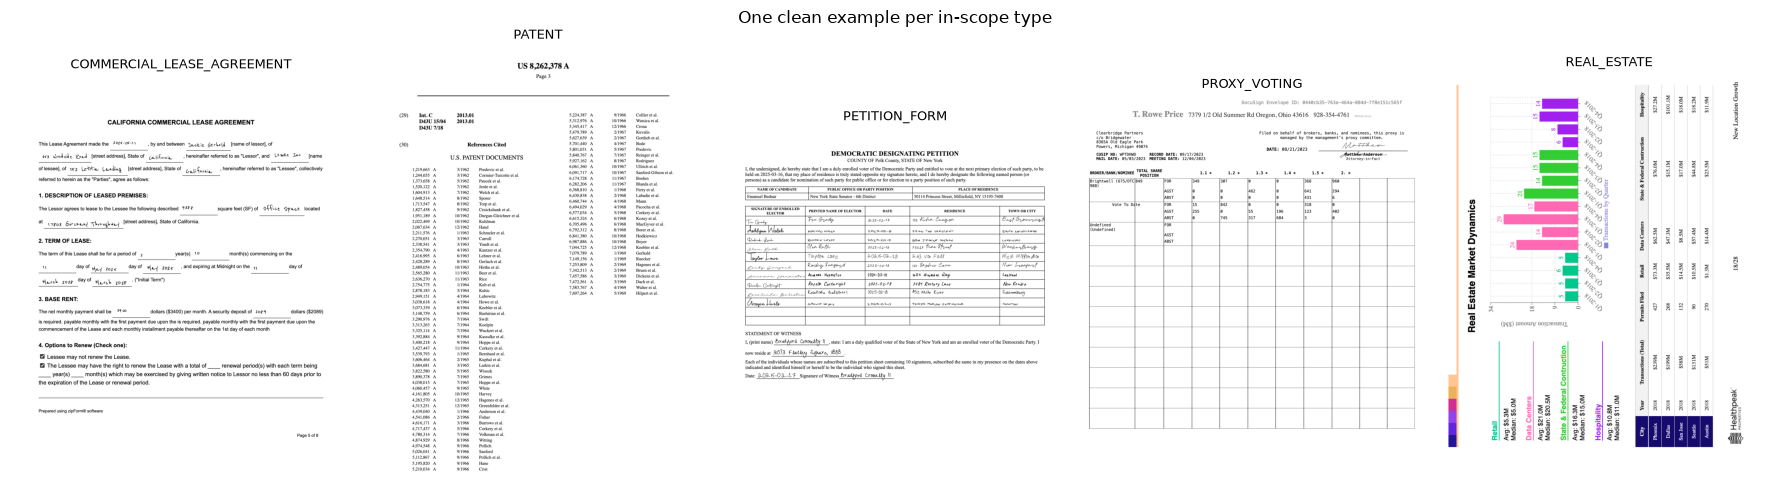

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for ax, fmt in zip(axes, sorted(labels.query("scope == @IN_SCOPE")["format"].unique())):
    idx = int(labels.query("format == @fmt and document_quality == 'CLEAN'")["id"].iloc[0])
    ax.imshow(ds[idx]["image"].convert("RGB"))
    ax.set_title(fmt, fontsize=9)
    ax.axis("off")
plt.suptitle("One clean example per in-scope type")
plt.tight_layout()
plt.show()